In [1]:
#!pip install transformers datasets torch scikit-learn pandas

**Setup: Install & Import Library**

In [1]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from pathlib import Path

from transformers import EarlyStoppingCallback

**Tahap 1: Membaca Dataset**

In [2]:
possible_paths = [
    Path('../dataset/dataset_clean_final.csv'),
    Path('dataset_clean_final.csv'),
    Path('/content/dataset_clean_final.csv')
]

for path in possible_paths:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Dataset berhasil dibaca dari: {path}")
        break
else:
    raise FileNotFoundError('File dataset_clean_final.csv tidak ditemukan. Pastikan file berada di folder dataset atau satu folder dengan notebook.')

Dataset berhasil dibaca dari: ..\dataset\dataset_clean_final.csv


In [3]:
# Load dataset
df = df.dropna(subset=['text', 'label'])
df.head()

,text,label
0,makin yakin habis baca review lain tentang vic...,1
1,paling suka model h2 smiling_face_with_heart e...,0
2,mobilnya sudah hancur pleading_face,0
3,manut88benar2 bikin aku jadi sultan,1
4,semoga lekas recover mobilnya mas dipo,0


**Tahap 2: Pembagian Dataset (80/20 Stratified)**

In [4]:
# Membagi dataset menjadi 80% Training dan 20% Validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label'] # Menjaga rasio label tetap seimbang
)

# Konversi format list biasa menjadi format 'Dataset' bawaan Hugging Face
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
val_dataset = Dataset.from_dict({'text': val_texts, 'label': val_labels})

print(f"Jumlah data latih: {len(train_dataset)}")
print(f"Jumlah data validasi: {len(val_dataset)}")

Jumlah data latih: 56303
Jumlah data validasi: 14076


**Tahap 3: Tokenisasi dengan IndoBERT**

In [5]:
# Menggunakan pre-trained model IndoBERT
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # max_length=128 cukup ideal untuk komentar YouTube
    # padding & truncation memastikan semua input memiliki panjang seragam
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Menerapkan tokenisasi ke seluruh data latih dan validasi secara massal (batched)
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

print("Proses tokenisasi selesai!")

Map:   0%|          | 0/56303 [00:00<?, ? examples/s]

Map:   0%|          | 0/14076 [00:00<?, ? examples/s]

Proses tokenisasi selesai!


**Tahap 4: Definisi Metrik Evaluasi**

In [6]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Menghitung metrik klasifikasi biner
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

**Tahap 5: Focal Loss & Custom Trainer (WeightedFocalTrainer)**

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

# 1. Definisi Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Hitung Cross Entropy standar
        CE_loss = F.cross_entropy(inputs, targets, reduction='none')

        # Probabilitas prediksi (pt)
        pt = torch.exp(-CE_loss)

        # Focal Modulator: (1 - pt)^gamma
        # Ini mengecilkan loss dari sampel yang MUDAH ditebak (kelas mayoritas)
        # dan membesarkan loss dari sampel yang SULIT (slang judol seperti 'wd', 'gacor')
        F_loss = ((1 - pt) ** self.gamma) * CE_loss

        # Aplikasikan Class Weight (alpha)
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            F_loss = at * F_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        return F_loss

# 2. Definisi Custom Trainer
class WeightedFocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Bobot Alpha: Kelas 0 = 1.0, Kelas 1 = 7.61 (Rasio 62227 / 8177)
        # Pindahkan tensor ke device yang sama dengan model (CPU/GPU)
        alpha = torch.tensor([1.0, 7.61], dtype=torch.float).to(logits.device)

        # Gamma = 2.0 adalah standar empiris untuk Focal Loss
        loss_fct = FocalLoss(alpha=alpha, gamma=2.0, reduction='mean')
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

**Tahap 6: Konfigurasi Model & Training Arguments**

In [8]:
# Memuat model IndoBERT dengan spesifikasi 2 label kelas klasifikasi
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Konfigurasi argumen pelatihan yang dioptimalkan untuk RTX 3050 (6GB)
training_args = TrainingArguments(
    output_dir="./indobert_judol_model_focal",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    dataloader_pin_memory=True,
    optim="adamw_torch_fused"
)

# Inisialisasi API Trainer
trainer = WeightedFocalTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Tahap 7: Proses Fine-Tuning IndoBERT**

In [10]:
# Memulai proses training
print("Memulai proses fine-tuning IndoBERT...")
trainer.train()

Memulai proses fine-tuning IndoBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.047896,0.028925,0.994317,0.975654,0.970927,0.980428
2,0.023871,0.031324,0.995808,0.981896,0.985222,0.978593
3,0.011075,0.040609,0.994885,0.978089,0.973349,0.982875
4,0.000743,0.052642,0.996022,0.982875,0.982875,0.982875
5,0.000379,0.053907,0.996377,0.984380,0.985890,0.982875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8800, training_loss=0.019459119474472986, metrics={'train_runtime': 3110.4206, 'train_samples_per_second': 90.507, 'train_steps_per_second': 2.829, 'total_flos': 1.85174271874176e+16, 'train_loss': 0.019459119474472986, 'epoch': 5.0})

**Tahap 8: Simpan Model & Tokenizer**

In [ ]:
# Menentukan nama folder penyimpanan
model_path = "../model/indobert_judol_model_focal"

# Menyimpan model dan tokenizer
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"Model berhasil disimpan di folder: {model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan di folder: ./model/indobert_judol_model_focal


**Tahap 9: Pengujian Inference dengan Pipeline**

In [9]:
from transformers import pipeline
model_path = "../model/indobert_judol_model_focal"

# Load model yang baru saja disimpan
classifier = pipeline("text-classification", model=model_path, tokenizer=model_path)

# Contoh teks pengujian
test_comments = [
    "Wah videonya sangat edukatif, terima kasih bang!",
    "Bongkar rahasia wd terus bosku, cek link di bio sekarang depo 10k jadi 100k",
    "Gacor banget bang mainnya, tutor dong",
    "Jangan lupa klaim bonus deposit pertama di situs zeus gampang menang hari ini!"
]

# Jalankan prediksi
predictions = classifier(test_comments)

for text, pred in zip(test_comments, predictions):
    # Pipeline mengembalikan label sebenarnya (BUKAN_JUDOL / JUDOL) karena id2label ada di config
    label = pred['label']
    print(f"Komentar: {text}")
    print(f"Prediksi: {label} (Confidence: {pred['score']:.4f})\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Komentar: Wah videonya sangat edukatif, terima kasih bang!
Prediksi: BUKAN_JUDOL (Confidence: 0.9866)

Komentar: Bongkar rahasia wd terus bosku, cek link di bio sekarang depo 10k jadi 100k
Prediksi: JUDOL (Confidence: 0.9799)

Komentar: Gacor banget bang mainnya, tutor dong
Prediksi: BUKAN_JUDOL (Confidence: 0.9688)

Komentar: Jangan lupa klaim bonus deposit pertama di situs zeus gampang menang hari ini!
Prediksi: JUDOL (Confidence: 0.9270)



**Tahap 10: Evaluasi Akhir — Classification Report & Confusion Matrix**

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil di-load dari: ../model/indobert_judol_model_focal
Menjalankan prediksi pada test set...



--- TEST DATA EVALUATION REPORT (IndoBERT + Focal Loss) ---
              precision    recall  f1-score   support

 Bukan Judol       1.00      1.00      1.00     12441
       Judol       0.99      0.98      0.98      1635

    accuracy                           1.00     14076
   macro avg       0.99      0.99      0.99     14076
weighted avg       1.00      1.00      1.00     14076



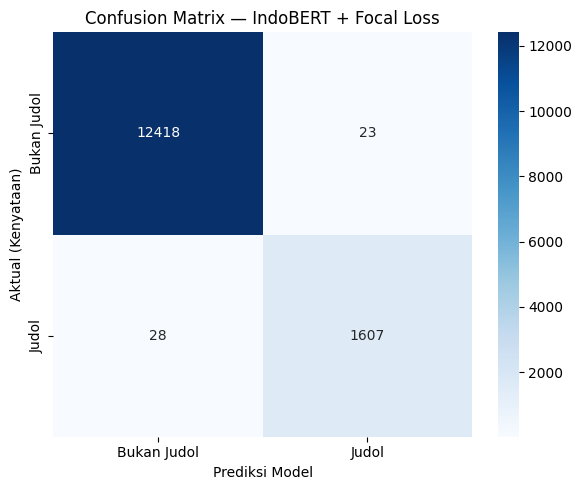

In [11]:
# Load model dari disk (tidak bergantung pada trainer in-memory)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
print(f"Model berhasil di-load dari: {model_path}")

# Trainer minimal untuk prediksi saja (compute_loss tidak dipakai saat predict)
eval_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./eval_temp",
        per_device_eval_batch_size=64,
        report_to="none",
        skip_memory_metrics=True,
        do_train=False,
        dataloader_pin_memory=True,
    ),
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Jalankan prediksi pada seluruh test set
print("Menjalankan prediksi pada test set...")
predictions_output = eval_trainer.predict(tokenized_val)

# Ambil prediksi dan label asli
preds_np = predictions_output.predictions.argmax(-1)
labels_np = predictions_output.label_ids

# Classification Report
print("\n--- TEST DATA EVALUATION REPORT (IndoBERT + Focal Loss) ---")
print(classification_report(labels_np, preds_np, target_names=['Bukan Judol', 'Judol']))

# Confusion Matrix
cm = confusion_matrix(labels_np, preds_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan Judol', 'Judol'],
            yticklabels=['Bukan Judol', 'Judol'])
plt.ylabel('Aktual (Kenyataan)')
plt.xlabel('Prediksi Model')
plt.title('Confusion Matrix — IndoBERT + Focal Loss')
plt.tight_layout()
plt.show()

**Tahap 11: Error Analysis — False Positive & False Negative**

In [12]:
# Mengambil confidence score (probabilitas) untuk prediksi yang salah
probs = torch.softmax(torch.tensor(predictions_output.predictions), dim=-1)
confidence = probs.max(dim=-1).values.numpy()

# Membuat DataFrame error untuk analisis
error_df = pd.DataFrame({
    'text': val_texts,
    'label_asli': labels_np,
    'prediksi': preds_np,
    'confidence': confidence
})

# False Positive: model prediksi JUDOL, tapi aslinya BUKAN JUDOL (label 0, pred 1)
fp = error_df[(error_df['label_asli'] == 0) & (error_df['prediksi'] == 1)]
fp_sorted = fp.sort_values('confidence', ascending=False)

# False Negative: model prediksi BUKAN JUDOL, tapi aslinya JUDOL (label 1, pred 0)
fn = error_df[(error_df['label_asli'] == 1) & (error_df['prediksi'] == 0)]
fn_sorted = fn.sort_values('confidence', ascending=False)

print(f"Total False Positive (FP): {len(fp)} — komentar aman yang salah dikira judol")
print(f"Total False Negative (FN): {len(fn)} — komentar judol yang lolos deteksi")
print()

print("--- TOP 10 FALSE POSITIVE (Aman tapi dikira Judol) ---")
for i, row in fp_sorted.head(10).iterrows():
    print(f"  [{row['confidence']:.4f}] \"{row['text'][:100]}\"")

print()
print("--- TOP 10 FALSE NEGATIVE (Judol tapi lolos deteksi) ---")
for i, row in fn_sorted.head(10).iterrows():
    print(f"  [{row['confidence']:.4f}] \"{row['text'][:100]}\"")

Total False Positive (FP): 23 — komentar aman yang salah dikira judol
Total False Negative (FN): 28 — komentar judol yang lolos deteksi

--- TOP 10 FALSE POSITIVE (Aman tapi dikira Judol) ---
  [0.9921] "tidak pernah merasa jenuh bermain di o a 7 7 selalu ada inovasi cool_button"
  [0.9868] "mk88 p2w jago di mulut doang"
  [0.9851] "jangan tergiur kemenangan palsu situs seperti probet855 cuma jebakan spider_web"
  [0.9842] "link gacor"
  [0.9751] "baru kali ini ada cerita nyangkut77 pasti tidak win face_with_tears_of_joy face_with_tears_of_joy fa"
  [0.9712] "pulau 77 itu judol tai jangan ikut"
  [0.9688] ": hand pink waving : natunatoto : hand pink waving : pasti gacor : hand pink waving : : hand pink wa"
  [0.9640] "kontennya bikin baper pengen ikutan lihat langsung suasananya grinning_squinting_face"
  [0.9499] "pulauwin pulauwin kepala otak kamu pulauwin"
  [0.9441] "tot8858 eh tot bedain jawaban diplomatis sama normatif"

--- TOP 10 FALSE NEGATIVE (Judol tapi lolos deteksi) ---
  